Ejercicio 1

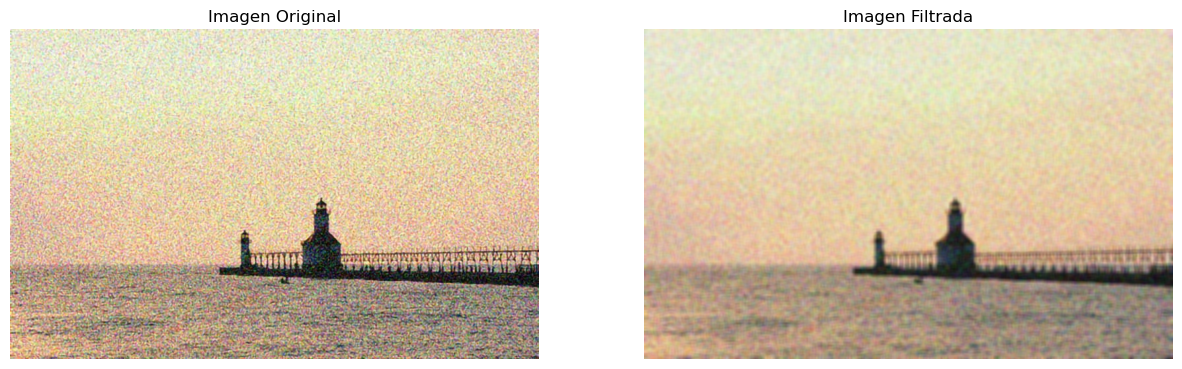

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import morphology
from scipy.ndimage import binary_erosion

def convMediaHor(imagen, tamanioK):
    kernel = np.ones((1, tamanioK), np.float32) / tamanioK
    kernel2 = np.ones((tamanioK, 1), np.float32) / tamanioK
    imgFin = cv2.filter2D(imagen, -1, kernel)
    imgFin = cv2.filter2D(imgFin, -1, kernel2)
    return imgFin

imagen = cv2.imread("segundo momento evaluativo/ruido.jpg")

gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

img = convMediaHor(gris, 7)

plt.figure(figsize=(15, 10))
plt.subplot(121)
plt.title("Imagen Original")
plt.axis("off")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))

plt.subplot(122)
plt.title("Imagen Filtrada")
plt.axis("off")
plt.imshow(img)
plt.show()

Ejercicio 2

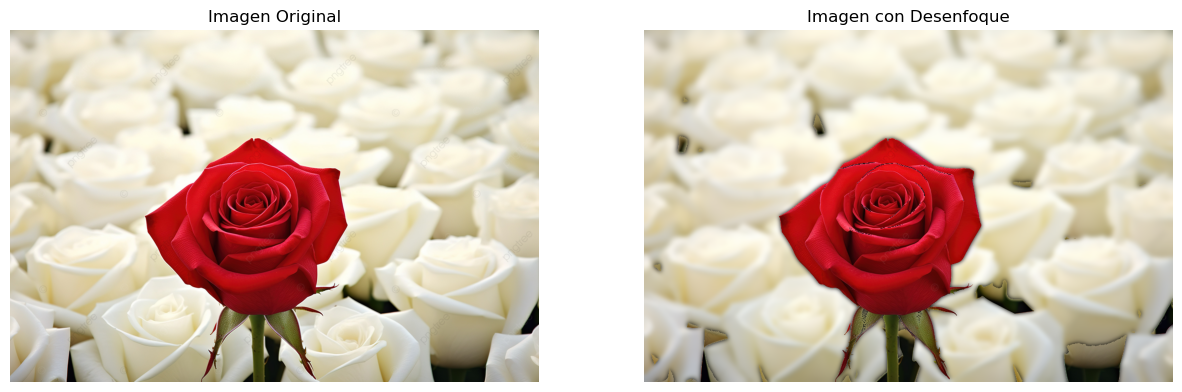

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def desenfoquePOI(img, mask):
    copia = np.copy(img)
    mask = cv2.resize(mask, (img.shape[1], img.shape[0]))
    img_mask = cv2.bitwise_and(img, img, mask=mask)
    blur = cv2.GaussianBlur(img_mask, (25, 25), 0)
    copia[mask != 0] = blur[mask != 0]
    return copia

img = cv2.imread('segundo momento evaluativo/rosa.png')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)

_, binarized = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV)

cant, region = cv2.connectedComponents(binarized)
colores = np.random.randint(0, 255, size=(cant, 3), dtype=np.uint8)
colores[0] = [0, 0, 0]
region_coloreada = colores[region]
_, umbral_bin = cv2.threshold(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), 127, 255, cv2.THRESH_BINARY)

imgBlur = desenfoquePOI(imgRGB, umbral_bin)

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.title('Imagen Original')
plt.imshow(imgRGB)
plt.axis('off')

plt.subplot(122)
plt.title('Imagen con Desenfoque')
plt.imshow(imgBlur)
plt.axis('off')
plt.show()

Ejercicio 3

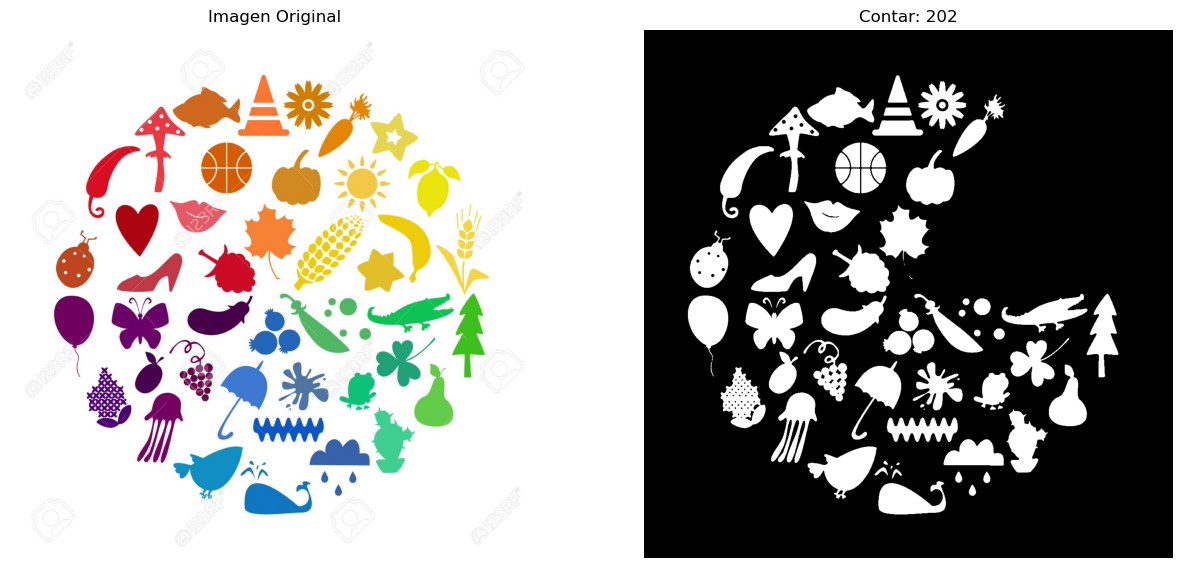

In [181]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

imagen = cv2.imread('segundo momento evaluativo/elementos.jpg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)

_, umbral_bin = cv2.threshold(blur, 151, 255, cv2.THRESH_BINARY_INV)
_, binarized = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

cant, region = cv2.connectedComponents(umbral_bin)
colores = np.random.randint(0, 255, size=(cant, 3), dtype=np.uint8)
for i in range(len(colores)):
    colores[i] = [255, 255, 255]
colores[0] = [0, 0, 0]
region_coloreada = colores[region]

imgCANNY = cv2.Canny(region_coloreada, 100, 200)

contornos, _ = cv2.findContours(imgCANNY, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

plt.figure(figsize=(15, 10))
plt.subplot(121)
plt.title('Imagen Original')
plt.imshow(imagen_rgb)
plt.axis('off')

plt.subplot(122)
plt.title(f'Contar: {len(contornos)}')
plt.imshow(binarized, cmap='gray')
plt.axis('off')
plt.show()

Ejercicio 4

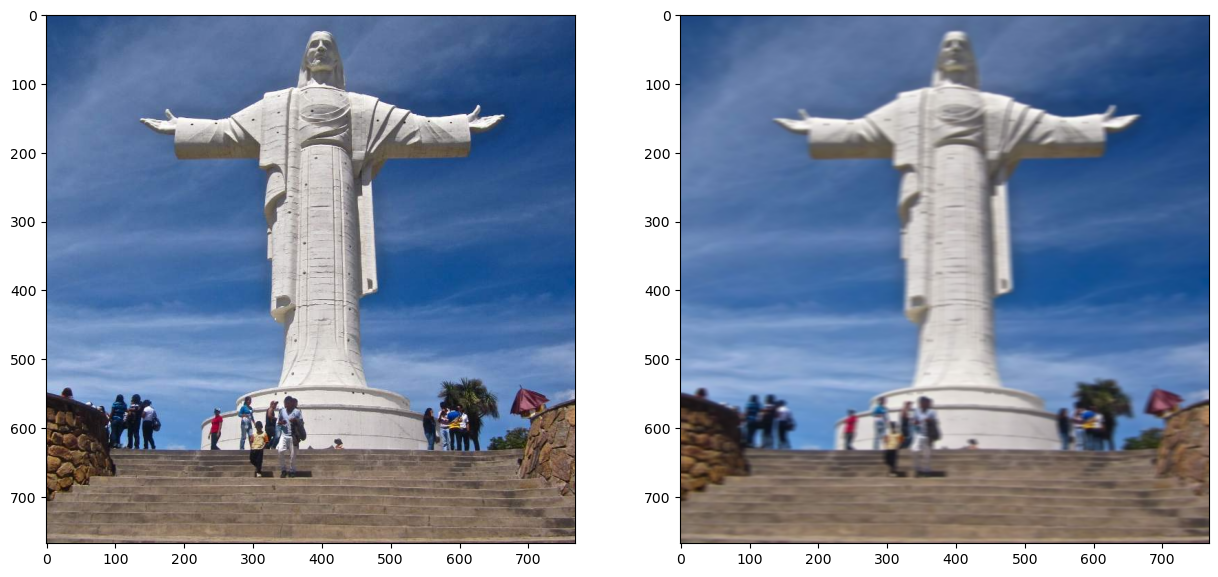

In [214]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convMediaHor(imagen, tamanioK):
    kernel = np.ones((tamanioK, 1), np.float32) / tamanioK
    kernel2 = np.ones((1, tamanioK), np.float32) / tamanioK
    imgFin = cv2.filter2D(imagen, -1, kernel)
    imgFin = cv2.filter2D(imagen, -1, kernel2)
    return imgFin

imagen = cv2.imread("segundo momento evaluativo/cristo.jpg")

gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

blur = cv2.GaussianBlur(gris, (5, 5), 0)

img = convMediaHor(blur, 10)

plt.figure(figsize=(15, 10))
plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))

plt.subplot(122)
plt.imshow(img)
plt.show()

Ejercicio 5

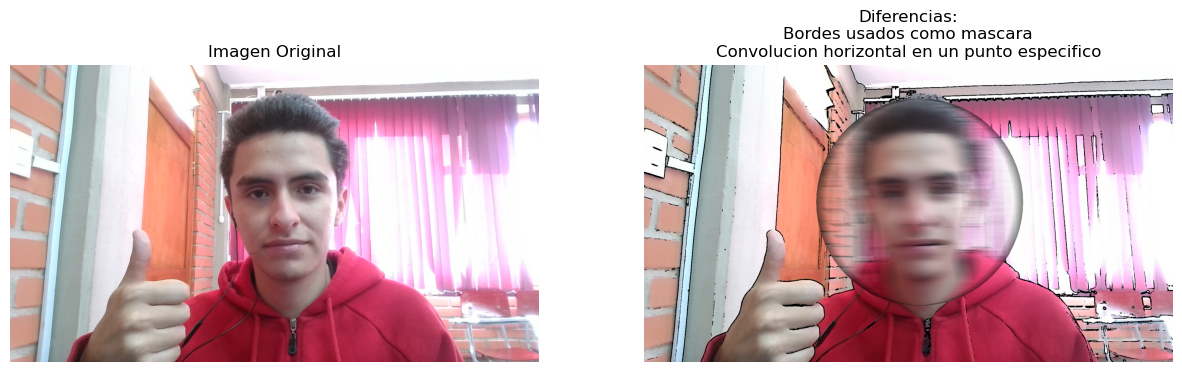

In [160]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sobelMejorado(img, kernel = 3, umbral = 30):
    imgGRAY = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    imgGRAY = cv2.GaussianBlur(imgGRAY, (3, 3), 0)

    sobelx = cv2.Sobel(imgGRAY, cv2.CV_64F, 1, 0, ksize=kernel)
    sobely = cv2.Sobel(imgGRAY, cv2.CV_64F, 0, 1, ksize=kernel)
    
    magSOBEL = cv2.magnitude(sobelx, sobely)
    
    magSOBEL = cv2.normalize(magSOBEL, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    _, bordes = cv2.threshold(magSOBEL, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernelMorf = np.ones((2, 2), np.uint8)
    sobFinal = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernelMorf)
    return sobFinal

def convMediaHor(imagen, tamanioK):
    kernel = np.ones((1, tamanioK), np.float32) / tamanioK
    imgFin = cv2.filter2D(imagen, -1, kernel)
    return imgFin

def desenfoquePOI(img, centro, x, y):
    copia = np.copy(img)
    valx, valy = centro
    mediox = x // 2
    medioy = y // 2
    mask = np.zeros_like(img, dtype=np.uint8)
    cv2.ellipse(mask, (valx, valy), (mediox, medioy), 0, 0, 360, (255, 255, 255), -1)
    img_mask = cv2.bitwise_and(img, mask)
    blur = convMediaHor(img_mask, 75)
    copia[mask != 0] = blur[mask != 0]
    return copia

imagen = cv2.imread("segundo momento evaluativo/foto.jpg")
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
imagen_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

bordes = sobelMejorado(imagen_rgb)
bordes_inv = cv2.bitwise_not(bordes)
img = cv2.bitwise_and(imagen_rgb, imagen_rgb, mask=bordes_inv)

imgFinal = desenfoquePOI(img, (1000, 500), 750, 750)

plt.figure(figsize=(15, 10))
plt.subplot(121)
plt.title("Imagen Original")
plt.imshow(imagen_rgb)
plt.axis('off')

plt.subplot(122)
plt.title("Diferencias:\nBordes usados como mascara\nConvolucion horizontal en un punto especifico")
plt.imshow(imgFinal)
plt.axis('off')
plt.show()

Ejercicio 6

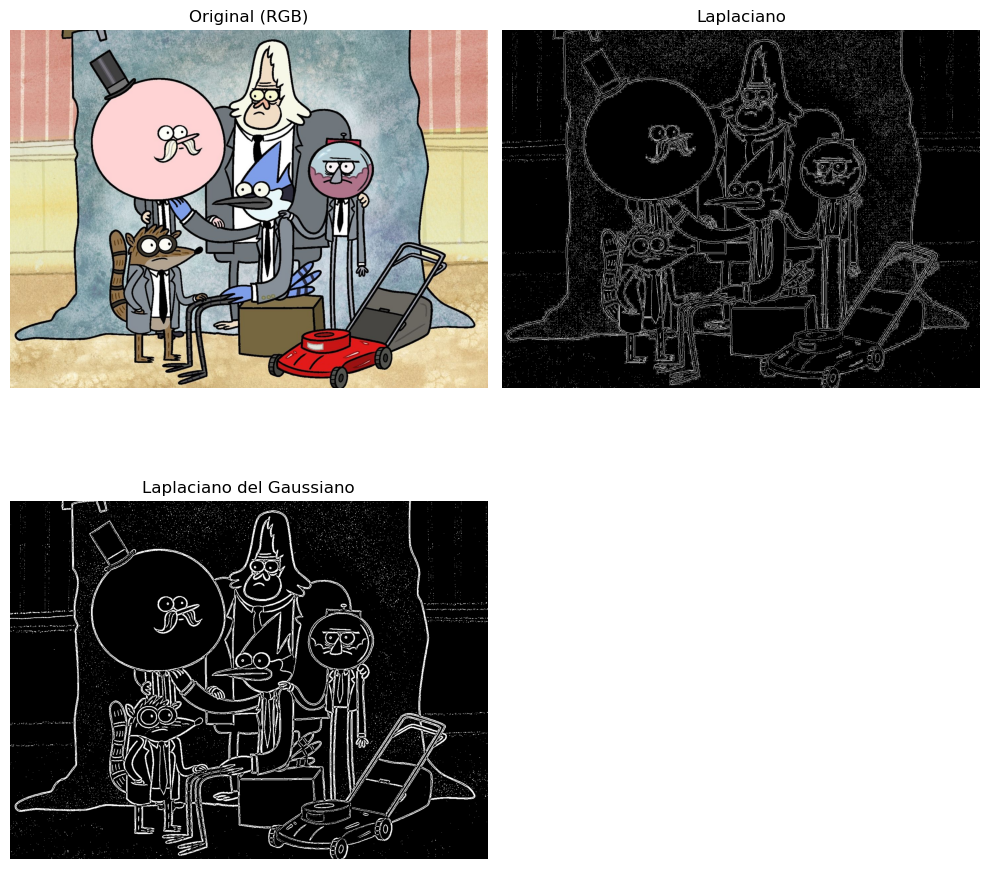

In [199]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imagen.jpg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
imagen_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

laplaciano = cv2.Laplacian(imagen_gray, cv2.CV_64F)

gauss = cv2.GaussianBlur(imagen_gray, (5, 5), sigmaX=1)

lapGauss = cv2.Laplacian(gauss, cv2.CV_64F)

_, lap = cv2.threshold(laplaciano, 35, 255, cv2.THRESH_BINARY)
_, gauss = cv2.threshold(lapGauss, 10, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 10))

plt.subplot(221)
plt.title("Original (RGB)")
plt.imshow(imagen_rgb)
plt.axis('off')

plt.subplot(222)
plt.title("Laplaciano")
plt.imshow(np.abs(lap), cmap='gray')
plt.axis('off')

plt.subplot(223)
plt.title("Laplaciano del Gaussiano")
plt.imshow(np.abs(gauss), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()